カーネル行列 K を計算中...
計算完了！
逆問題解析を開始します...
反復 2回で収束 (Chi^2 = 0.268)


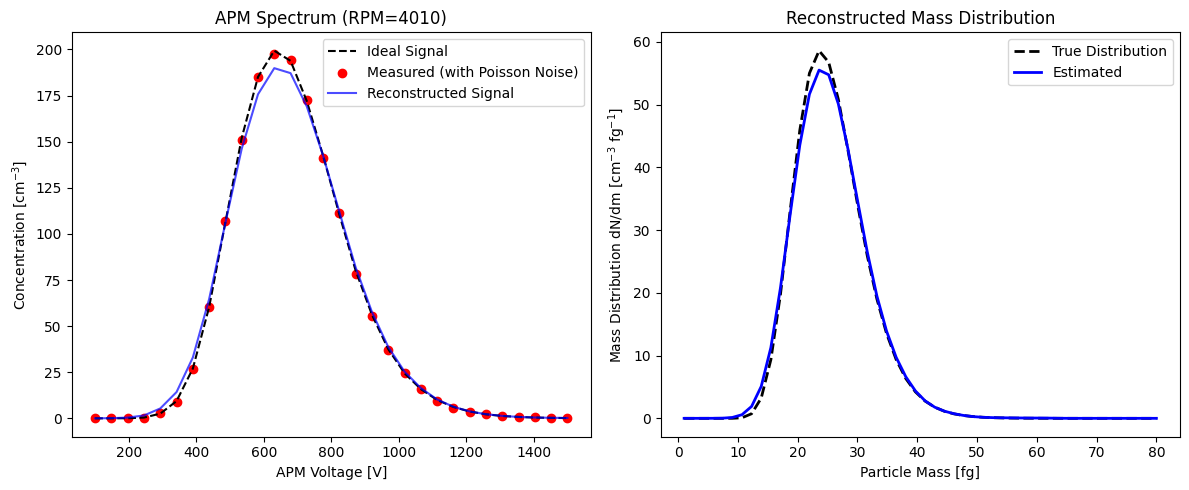

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import lognorm

# ==========================================
# 1. 物理定数とAPM/DMAの条件設定
# ==========================================
e = 1.60219e-19
vis = 1.83e-5
P = 1.013e5
PI = np.pi

# APM設定 (Model 3601)
L = 100.0e-3
r1 = 24.0e-3
r2 = 25.0e-3
rc = 0.5 * (r1 + r2)
delta = 0.5 * (r2 - r1)

# 運転条件
Q_a_lpm = 0.3             # APMエアロゾル流量 [L/min]
Q = Q_a_lpm * 1e-3 / 60.0 # [m^3/s]
RPM = 4010.0              # APM回転数
omega = RPM / 60.0 * 2.0 * PI

# DMA条件
Dmob = 450.0e-9           # [m]
Cc = 1.0 + 1.0 / (P * 1e-3 * Dmob * 1e6) * \
     (15.60 + 7.00 * np.exp(-0.059 * (P * 1e-3 * Dmob * 1e6)))

# 測定システム条件 (CPCのカウントノイズ計算用)
Q_cpc_ccps = (0.3 * 1000) / 60.0 # CPC流量 [cm^3/s] (0.3 L/minを仮定)
t_meas = 10.0                    # 各電圧ステップでのサンプリング時間 [s]
V_sample = Q_cpc_ccps * t_meas   # 1ステップあたりの吸引体積 [cm^3]

dz = 1.0e-4
nr0 = 1000

# ==========================================
# 2. 透過率関数(カーネル)の数値計算
# ==========================================
def calc_transfer_efficiency(m, V):
    r0 = np.linspace(r1 + 1e-5, r2 - 1e-5, nr0)
    r = r0.copy()
    weights = 1.5 * (1.0 - ((r0 - rc) / delta)**2)
    total_weight = np.sum(weights)

    coef = dz * 8.0 / (9.0 * vis) * (Cc / Dmob) * (delta * rc) / Q
    V_term = e * V / np.log(r2 / r1)

    active = np.ones(nr0, dtype=bool)
    num_steps = int(L / dz)

    for _ in range(num_steps):
        if not np.any(active): break
        ra = r[active]
        def f(rad):
            return coef * (m * omega**2 * rad - V_term / rad) / (1.0 - ((rad - rc) / delta)**2)

        k1 = f(ra)
        k2 = f(ra + 0.5 * k1)
        k3 = f(ra + 0.5 * k2)
        k4 = f(ra + k3)
        r[active] = ra + (k1 + 2.0*k2 + 2.0*k3 + k4) / 6.0
        active[active] = np.abs(r[active] - rc) < (delta - 1e-5)

    return np.sum(weights[active]) / total_weight

# ==========================================
# 3. 逆問題用 カーネル行列 K の構築
# ==========================================
V_array = np.linspace(100, 1500, 30)
I = len(V_array)

m_min, m_max = 5.0e-18, 8.0e-17 # 5 fg ~ 80 fg [kg]
J = 50
m_array = np.linspace(m_min, m_max, J)
dm = m_array[1] - m_array[0]    # 質量ビンの幅 [kg]

print("カーネル行列 K を計算中...")
K = np.zeros((I, J))
for i, V in enumerate(V_array):
    for j, m in enumerate(m_array):
        # ★修正2: 行列要素に dm を掛ける (積分 K * f * dm の離散化)
        K[i, j] = calc_transfer_efficiency(m, V) * dm
print("計算完了！")

# ==========================================
# 4. 模擬データの生成 (ポアソンノイズの厳密化)
# ==========================================
# 真の質量分布 dN/dm (積分して総濃度が約800 cm^-3になるよう設定)
true_m_center = 2.5e-17
sigma_g = 1.25
f_true = lognorm.pdf(m_array, s=np.log(sigma_g), scale=true_m_center)
f_true = f_true / np.sum(f_true * dm) * 800.0 # 総濃度 800 cm^-3

# 理想的な濃度 [cm^-3]
n_ideal = K @ f_true

# ★修正3: カウント数ベースでのポアソンノイズ付加
count_ideal = n_ideal * V_sample
np.random.seed(42)
count_meas = np.random.poisson(count_ideal)
n_meas = count_meas / V_sample # 濃度 [cm^-3] に戻す

# ==========================================
# 5. Chahine-Twomey 法 (Markowski平滑化つき)
# ==========================================
def solve_chahine_twomey(K_matrix, meas_data, max_iter=1000, chi_threshold=1.0):
    # 初期推測 (一様分布)
    f_est = np.ones(J) * (np.sum(meas_data) / (m_max - m_min))
    K_norm = K_matrix / np.max(K_matrix)

    print("逆問題解析を開始します...")
    for k in range(max_iter):
        calc_n = K_matrix @ f_est
        calc_n = np.maximum(calc_n, 1e-10)

        # カイ二乗値 (ポアソン統計に基づく重み)
        chi_sq = np.sum(((meas_data - calc_n)**2) / np.maximum(calc_n, 1.0/V_sample)) / I
        if chi_sq < chi_threshold:
            print(f"反復 {k}回で収束 (Chi^2 = {chi_sq:.3f})")
            break

        # ★修正1: Chahine型の更新式 (加重平均)
        ratio = meas_data / calc_n
        f_new = np.copy(f_est)
        for j in range(J):
            correction = np.sum(ratio * K_norm[:, j]) / max(np.sum(K_norm[:, j]), 1e-10)
            f_new[j] = f_est[j] * max(correction, 0.01)

        # 内部平滑化 (1-2-1 移動平均)
        f_smooth = np.copy(f_new)
        f_smooth[1:-1] = 0.25 * f_new[:-2] + 0.5 * f_new[1:-1] + 0.25 * f_new[2:]
        f_est = np.copy(f_smooth)

    else:
        print(f"最大反復回数 {max_iter} に到達 (Chi^2 = {chi_sq:.3f})")

    return f_est

# 解析の実行
f_estimated = solve_chahine_twomey(K, n_meas)

# 最終的な推定質量分布(f_estimated)を用いて、順問題により再構成APMスペクトルを厳密に計算する
n_reconstructed = K @ f_estimated

# ==========================================
# 6. 結果のプロット
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(V_array, n_ideal, 'k--', label='Ideal Signal')
ax1.scatter(V_array, n_meas, color='red', label='Measured (with Poisson Noise)')
ax1.plot(V_array, n_reconstructed, 'b-', alpha=0.7, label='Reconstructed Signal')
ax1.set_xlabel('APM Voltage [V]')
ax1.set_ylabel('Concentration [cm$^{-3}$]')
ax1.set_title('APM Spectrum (RPM=4010)')
ax1.legend()

# 質量分布のプロット (dN/dm [cm^-3 / fg] に単位換算して見やすくする)
ax2.plot(m_array * 1e18, f_true * 1e-18, 'k--', linewidth=2, label='True Distribution')
ax2.plot(m_array * 1e18, f_estimated * 1e-18, 'b-', linewidth=2, label='Estimated')
ax2.set_xlabel('Particle Mass [fg]')
ax2.set_ylabel('Mass Distribution dN/dm [cm$^{-3}$ fg$^{-1}$]')
ax2.set_title('Reconstructed Mass Distribution')
ax2.legend()

plt.tight_layout()
plt.show()